# Olist E-Commerce Analytics — Phase 2: Python EDA

This notebook connects Python/Jupyter Notebook with the SQL Server database **OlistEcommerce** and performs exploratory data analysis for the Olist e-commerce dataset.

## Objective

The objective of this notebook is to prepare a clean analytical foundation for:
- business KPI analysis,
- customer and order behavior analysis,
- product/category performance analysis,
- delivery and review analysis,
- and the next phase: time series forecasting.

## 1. Environment Setup



In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
import pyodbc
import urllib

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

PROJECT_DIR = Path.cwd()
REPORTS_DIR = PROJECT_DIR / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

REPORTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

print("Setup completed.")
print("Project folder:", PROJECT_DIR)
print("Reports folder:", REPORTS_DIR)
print("Figures folder:", FIGURES_DIR)

Setup completed.
Project folder: C:\Users\ayush\OneDrive\Desktop\OlistProject
Reports folder: C:\Users\ayush\OneDrive\Desktop\OlistProject\reports
Figures folder: C:\Users\ayush\OneDrive\Desktop\OlistProject\reports\figures


## 2. Connect Jupyter Notebook to SQL Server


In [2]:
server = "Ayush"
database = "OlistEcommerce"

available_drivers = pyodbc.drivers()
available_drivers

['SQL Server',
 'ODBC Driver 17 for SQL Server',
 'ODBC Driver 18 for SQL Server',
 'Microsoft Access Driver (*.mdb, *.accdb)',
 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)',
 'Microsoft Access Text Driver (*.txt, *.csv)',
 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)']

In [3]:
# Prefer Driver 18 if available, otherwise use Driver 17.
if "ODBC Driver 18 for SQL Server" in available_drivers:
    driver = "ODBC Driver 18 for SQL Server"
elif "ODBC Driver 17 for SQL Server" in available_drivers:
    driver = "ODBC Driver 17 for SQL Server"
else:
    raise RuntimeError(
        "No suitable SQL Server ODBC driver found. "
        "Install ODBC Driver 17 or 18 for SQL Server."
    )

connection_string = (
    f"DRIVER={{{driver}}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

params = urllib.parse.quote_plus(connection_string)

engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

print("Using driver:", driver)
print("Engine created successfully.")

Using driver: ODBC Driver 18 for SQL Server
Engine created successfully.


### 2.1 Test the Connection

This query checks whether Python can read data from SQL Server.

In [4]:
test_query = """
SELECT TOP 5 *
FROM olist_orders;
"""

test_df = pd.read_sql(test_query, engine)
test_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


## 3. Load Required Tables from SQL Server.

In [5]:
tables = {
    "orders": "olist_orders",
    "order_items": "olist_order_items",
    "payments": "olist_order_payments",
    "reviews": "olist_order_reviews",
    "products": "olist_products",
    "customers": "olist_customers",
    "sellers": "olist_sellers",
    "geolocation": "olist_geolocation",
    "category_translation": "product_category_name_translation"
}

data = {}

for key, table in tables.items():
    query = f"SELECT * FROM {table};"
    data[key] = pd.read_sql(query, engine)
    print(f"{key:22s} -> {data[key].shape[0]:,} rows, {data[key].shape[1]:,} columns")

orders = data["orders"]
order_items = data["order_items"]
payments = data["payments"]
reviews = data["reviews"]
products = data["products"]
customers = data["customers"]
sellers = data["sellers"]
geolocation = data["geolocation"]
category_translation = data["category_translation"]

orders                 -> 99,441 rows, 8 columns
order_items            -> 112,650 rows, 7 columns
payments               -> 103,886 rows, 5 columns
reviews                -> 99,224 rows, 7 columns
products               -> 32,951 rows, 9 columns
customers              -> 99,441 rows, 5 columns
sellers                -> 3,095 rows, 4 columns
geolocation            -> 1,000,163 rows, 5 columns
category_translation   -> 72 rows, 2 columns


## 4. Data Overview

In [6]:
overview = pd.DataFrame({
    "table_name": list(data.keys()),
    "rows": [df.shape[0] for df in data.values()],
    "columns": [df.shape[1] for df in data.values()]
}).sort_values("rows", ascending=False)

overview

,table_name,rows,columns
7,geolocation,1000163,5
1,order_items,112650,7
2,payments,103886,5
0,orders,99441,8
5,customers,99441,5
3,reviews,99224,7
4,products,32951,9
6,sellers,3095,4
8,category_translation,72,2


In [7]:
for name, df in data.items():
    print("\n" + "=" * 80)
    print(name.upper())
    print("=" * 80)
    print(df.dtypes)


ORDERS
order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

ORDER_ITEMS
order_id                          str
order_item_id                   int64
product_id                        str
seller_id                         str
shipping_limit_date    datetime64[us]
price                         float64
freight_value                 float64
dtype: object

PAYMENTS
order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int64
payment_value           float64
dtype: object

REVIEWS
review_id                             str
order_id                              str
review_score            

## 5. Convert Date Columns

Some date columns may come from SQL Server as object/string depending on import settings.  
This cell safely converts order date columns into datetime format.

In [8]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    if col in orders.columns:
        orders[col] = pd.to_datetime(orders[col], errors="coerce")

orders[date_columns].head()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


## 6. Missing Value Analysis

In [9]:
def missing_summary(df, table_name):
    result = pd.DataFrame({
        "table_name": table_name,
        "column": df.columns,
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().sum().values / len(df) * 100).round(2)
    })
    return result[result["missing_count"] > 0].sort_values("missing_pct", ascending=False)

missing_all = pd.concat(
    [missing_summary(df, name) for name, df in data.items()],
    ignore_index=True
)

missing_all

,table_name,column,missing_count,missing_pct
0,orders,order_delivered_customer_date,2965,2.98
1,orders,order_delivered_carrier_date,1783,1.79
2,orders,order_approved_at,160,0.16
3,reviews,review_comment_title,87658,88.34
4,reviews,review_comment_message,58256,58.71
5,products,product_category_name,610,1.85
6,products,product_name_lenght,610,1.85
7,products,product_description_lenght,610,1.85
8,products,product_photos_qty,610,1.85
9,products,product_weight_g,2,0.01


## 7. Duplicate Key Checks

In [10]:
duplicate_checks = {
    "orders.order_id": orders["order_id"].duplicated().sum() if "order_id" in orders.columns else None,
    "customers.customer_id": customers["customer_id"].duplicated().sum() if "customer_id" in customers.columns else None,
    "products.product_id": products["product_id"].duplicated().sum() if "product_id" in products.columns else None,
    "sellers.seller_id": sellers["seller_id"].duplicated().sum() if "seller_id" in sellers.columns else None,
    "reviews.review_id": reviews["review_id"].duplicated().sum() if "review_id" in reviews.columns else None,
}

pd.DataFrame(
    duplicate_checks.items(),
    columns=["key_column", "duplicate_count"]
)

,key_column,duplicate_count
0,orders.order_id,0
1,customers.customer_id,0
2,products.product_id,0
3,sellers.seller_id,0
4,reviews.review_id,814


### Duplicate Review Investigation

The `reviews` table contains duplicate `review_id` values. Investigation showed that the same `review_id` can be associated with different `order_id` values. Therefore, these are not duplicate records but valid observations in the dataset.

**Decision:** No duplicate rows were removed from the `reviews` table.

In [11]:
# ==========================================================
# INVESTIGATE DUPLICATE REVIEW IDs
# ==========================================================

duplicate_reviews = (
    reviews[reviews.duplicated("review_id", keep=False)]
    .sort_values("review_id")
)

print(f"Total duplicate rows: {len(duplicate_reviews)}")

duplicate_reviews.head(20)

Total duplicate rows: 1603


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
46678,00130cbe1f9d422698c812ed8ded1919,dfcdfc43867d1c1381bfaf62d6b9c195,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07,2018-03-20 18:08:23
29841,00130cbe1f9d422698c812ed8ded1919,04a28263e085d399c97ae49e0b477efa,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07,2018-03-20 18:08:23
90677,0115633a9c298b6a98bcbe4eee75345f,78a4201f58af3463bdab842eea4bc801,5,NaN,NaN,2017-09-21,2017-09-26 03:27:47
63193,0115633a9c298b6a98bcbe4eee75345f,0c9850b2c179c1ef60d2855e2751d1fa,5,NaN,NaN,2017-09-21,2017-09-26 03:27:47
92876,0174caf0ee5964646040cd94e15ac95e,f93a732712407c02dce5dd5088d0f47b,1,NaN,Produto entregue dentro de embalagem do fornec...,2018-03-07,2018-03-08 03:00:53
57280,0174caf0ee5964646040cd94e15ac95e,74db91e33b4e1fd865356c89a61abf1f,1,NaN,Produto entregue dentro de embalagem do fornec...,2018-03-07,2018-03-08 03:00:53
54832,017808d29fd1f942d97e50184dfb4c13,8daaa9e99d60fbba579cc1c3e3bfae01,5,NaN,NaN,2018-03-02,2018-03-05 01:43:30
99167,017808d29fd1f942d97e50184dfb4c13,b1461c8882153b5fe68307c46a506e39,5,NaN,NaN,2018-03-02,2018-03-05 01:43:30
20621,0254bd905dc677a6078990aad3331a36,5bf226cf882c5bf4247f89a97c86f273,1,NaN,O pedido consta de 2 produtos e até agora rece...,2017-09-09,2017-09-13 09:52:44
96080,0254bd905dc677a6078990aad3331a36,331b367bdd766f3d1cf518777317b5d9,1,NaN,O pedido consta de 2 produtos e até agora rece...,2017-09-09,2017-09-13 09:52:44


## 8. Build a Master Analytical Dataset

The raw data is split across multiple tables.  
For analysis, we create a master dataset by joining:

- orders,
- customers,
- order items,
- products,
- category translation,
- sellers,
- payments,
- and reviews.

Payments are aggregated first because one order can have multiple payment rows.

In [12]:
payment_summary = (
    payments
    .groupby("order_id", as_index=False)
    .agg(
        total_payment_value=("payment_value", "sum"),
        avg_installments=("payment_installments", "mean"),
        payment_types=("payment_type", lambda x: ", ".join(sorted(x.dropna().unique())))
    )
)

review_summary = (
    reviews
    .groupby("order_id", as_index=False)
    .agg(avg_review_score=("review_score", "mean"))
)

master = (
    orders
    .merge(customers, on="customer_id", how="left")
    .merge(order_items, on="order_id", how="left")
    .merge(products, on="product_id", how="left")
    .merge(category_translation, on="product_category_name", how="left")
    .merge(sellers, on="seller_id", how="left")
    .merge(payment_summary, on="order_id", how="left")
    .merge(review_summary, on="order_id", how="left")
)

master["order_value"] = master["price"].fillna(0) + master["freight_value"].fillna(0)

print("Master dataset shape:", master.shape)
print("Unique orders in master:", master["order_id"].nunique())
print("Total rows in order_items:", order_items.shape[0])
print("Total columns in master:", master.shape[1])

Master dataset shape: (113425, 35)
Unique orders in master: 99441
Total rows in order_items: 112650
Total columns in master: 35


The master dataset contains 113,425 rows and 35 columns.

There are 99,441 unique orders in the master dataset, which matches the order-level structure of the original orders table.  
However, the total number of rows is higher because the master dataset is at the order-item level after joining with the order_items table.

Some orders also do not have matching product/item-level information, but they are retained because a left join was used from the orders table.  
This ensures that no order records are lost while creating the analytical dataset.

Therefore, the master dataset is suitable for further exploratory analysis across orders, customers, products, sellers, payments, reviews, and delivery performance.

## 9. Feature Engineering

We create useful variables for EDA:

- order year,
- order month,
- weekday,
- hour,
- delivery days,
- delivery delay,
- and late delivery flag.

In [13]:
master["order_year"] = master["order_purchase_timestamp"].dt.year
master["order_month"] = master["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()
master["order_weekday"] = master["order_purchase_timestamp"].dt.day_name()
master["order_hour"] = master["order_purchase_timestamp"].dt.hour

master["delivery_days"] = (
    master["order_delivered_customer_date"] - master["order_purchase_timestamp"]
).dt.days

master["delivery_delay_days"] = (
    master["order_delivered_customer_date"] - master["order_estimated_delivery_date"]
).dt.days

master["is_late_delivery"] = np.where(master["delivery_delay_days"] > 0, 1, 0)

master[[
    "order_id",
    "order_status",
    "order_month",
    "order_value",
    "delivery_days",
    "delivery_delay_days",
    "is_late_delivery"
]].head()

,order_id,order_status,order_month,order_value,delivery_days,delivery_delay_days,is_late_delivery
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-01,38.71,8.00,-8.00,0
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-01,141.46,13.00,-6.00,0
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-01,179.12,9.00,-18.00,0
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-01,72.20,13.00,-13.00,0
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-01,28.62,2.00,-10.00,0


## 10. Executive KPIs

This section calculates high-level business indicators for delivered orders only.

In [14]:
delivered = master[master["order_status"] == "delivered"].copy()

executive_kpis = pd.DataFrame({
    "metric": [
        "Total delivered orders",
        "Total unique customers",
        "Total sellers",
        "Total sold products",
        "Total items sold",
        "Total revenue",
        "Average order value",
        "Average review score"
    ],
    "value": [
        delivered["order_id"].nunique(),
        delivered["customer_id"].nunique(),
        delivered["seller_id"].nunique(),
        delivered["product_id"].nunique(),
        delivered.shape[0],
        delivered["order_value"].sum(),
        delivered.groupby("order_id")["order_value"].sum().mean(),
        delivered.groupby("order_id")["avg_review_score"].mean().mean()
    ]
})

executive_kpis

,metric,value
0,Total delivered orders,"96,478.00"
1,Total unique customers,"96,478.00"
2,Total sellers,"2,970.00"
3,Total sold products,"32,216.00"
4,Total items sold,"110,197.00"
5,Total revenue,"15,419,773.75"
6,Average order value,159.83
7,Average review score,4.16


## 11. Order Status Analysis

This chart shows the distribution of order statuses.  
It helps identify how many orders were delivered, cancelled, unavailable, shipped, or still in other stages.

In [15]:
status_counts = (
    orders["order_status"]
    .value_counts()
    .reset_index()
)

status_counts.columns = ["order_status", "total_orders"]
status_counts["percentage"] = (status_counts["total_orders"] / status_counts["total_orders"].sum() * 100).round(2)

status_counts

,order_status,total_orders,percentage
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


The order status distribution shows that the majority of orders were successfully delivered.  
Out of all orders, 96,478 orders were delivered, representing 97.02% of the dataset.

Only a small proportion of orders were cancelled or unavailable.  
This indicates that most transactions in the Olist dataset were completed successfully, making delivered orders the most reliable subset for revenue, delivery, and customer satisfaction analysis.

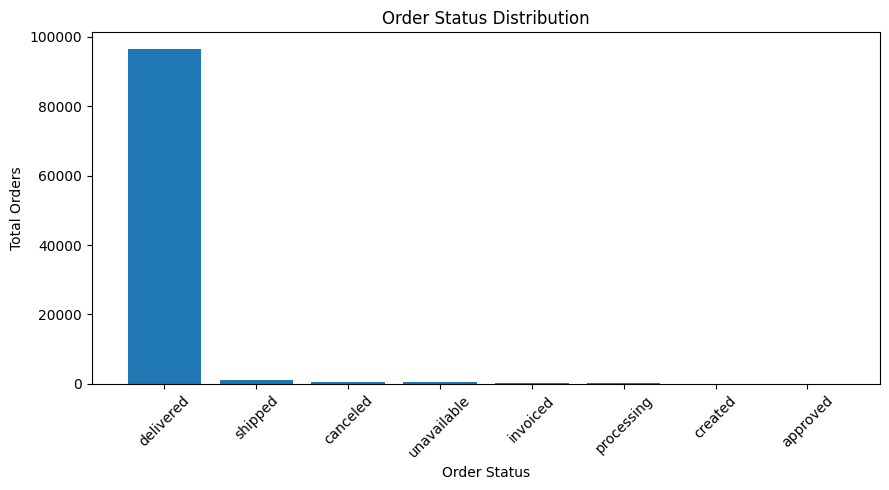

In [16]:
plt.figure(figsize=(9, 5))
plt.bar(status_counts["order_status"], status_counts["total_orders"])
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "order_status_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 12. Monthly Revenue Trend

Monthly revenue is one of the most important outputs because it becomes the base dataset for time series forecasting.

The calculation is done at order-item level and grouped by month for delivered orders.

In [17]:
monthly_sales_query ="""
WITH monthly_order_revenue AS (
    SELECT
        DATEFROMPARTS(
            YEAR(o.order_purchase_timestamp),
            MONTH(o.order_purchase_timestamp),
            1
        ) AS order_month,
        o.order_id,
        SUM(i.price + i.freight_value) AS order_value,
        SUM(i.price) AS product_revenue,
        SUM(i.freight_value) AS freight_revenue,
        SUM(i.price) AS total_price_sum,
        COUNT(i.order_item_id) AS total_items
    FROM olist_orders o
    JOIN olist_order_items i
        ON o.order_id = i.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_purchase_timestamp IS NOT NULL
    GROUP BY
        DATEFROMPARTS(
            YEAR(o.order_purchase_timestamp),
            MONTH(o.order_purchase_timestamp),
            1
        ),
        o.order_id
),
review_summary AS (
    SELECT
        order_id,
        AVG(CAST(review_score AS FLOAT)) AS avg_review_score
    FROM olist_order_reviews
    GROUP BY order_id
)
SELECT
    m.order_month,
    COUNT(DISTINCT m.order_id) AS total_orders,
    ROUND(SUM(m.order_value), 2) AS total_revenue,
    ROUND(SUM(m.product_revenue), 2) AS product_revenue,
    ROUND(SUM(m.freight_revenue), 2) AS freight_revenue,
    ROUND(SUM(m.total_price_sum) * 1.0 / SUM(m.total_items), 2) AS avg_item_price,
    ROUND(AVG(m.order_value), 2) AS avg_order_value,
    ROUND(AVG(r.avg_review_score), 2) AS avg_review_score
FROM monthly_order_revenue m
LEFT JOIN review_summary r
    ON m.order_id = r.order_id
GROUP BY m.order_month
ORDER BY m.order_month;
"""

monthly_sales = pd.read_sql(monthly_sales_query, engine)
monthly_sales["order_month"] = pd.to_datetime(monthly_sales["order_month"])
monthly_sales

,order_month,total_orders,total_revenue,product_revenue,freight_revenue,avg_item_price,avg_order_value,avg_review_score
0,2016-09-01,1,143.46,134.97,8.49,44.99,143.46,1.00
1,2016-10-01,265,"46,490.66","40,325.11","6,165.55",128.83,175.44,4.01
2,2016-12-01,1,19.62,10.90,8.72,10.90,19.62,5.00
3,2017-01-01,750,"127,482.37","111,798.36","15,684.01",122.45,169.98,4.20
4,2017-02-01,1653,"271,239.32","234,223.40","37,015.92",126.06,164.09,4.20
5,2017-03-01,2546,"414,330.95","359,198.85","55,132.10",123.99,162.74,4.19
6,2017-04-01,2303,"390,812.40","340,669.68","50,142.72",132.61,169.70,4.14
7,2017-05-01,3546,"566,851.40","489,338.25","77,513.15",122.21,159.86,4.24
8,2017-06-01,3135,"490,050.37","421,923.37","68,127.00",120.93,156.32,4.22
9,2017-07-01,3872,"566,299.08","481,604.52","84,694.56",109.06,146.25,4.26


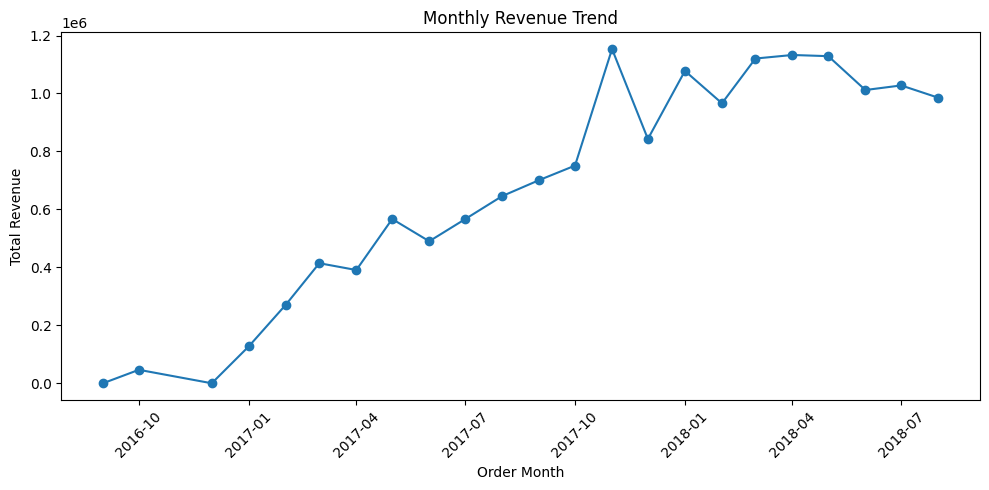

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_sales["order_month"], monthly_sales["total_revenue"], marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Order Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "monthly_revenue_trend.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
monthly_sales.to_csv(REPORTS_DIR / "monthly_sales_for_time_series.csv", index=False)
print("Saved:", REPORTS_DIR / "monthly_sales_for_time_series.csv")

Saved: C:\Users\ayush\OneDrive\Desktop\OlistProject\reports\monthly_sales_for_time_series.csv


## 13. Product Category Analysis

This section identifies the top product categories by revenue.

In [20]:
category_revenue = (
    delivered
    .assign(category=lambda x: x["product_category_name_english"].fillna(x["product_category_name"]).fillna("Unknown"))
    .groupby("category", as_index=False)
    .agg(
        total_orders=("order_id", "nunique"),
        total_revenue=("order_value", "sum"),
        avg_price=("price", "mean")
    )
    .sort_values("total_revenue", ascending=False)
    .head(10)
)

category_revenue

,category,total_orders,total_revenue,avg_price
44,health_beauty,8647,"1,412,089.53",130.28
73,watches_gifts,5495,"1,264,333.12",199.04
8,bed_bath_table,9272,"1,225,209.26",93.44
68,sports_leisure,7530,"1,118,256.91",113.25
16,computers_accessories,6530,"1,032,723.77",116.26
40,furniture_decor,6307,"880,329.92",87.25
50,housewares,5743,"758,392.25",90.60
21,cool_stuff,3559,"691,680.89",164.12
6,auto,3810,"669,454.75",139.85
43,garden_tools,3448,"567,145.68",110.24


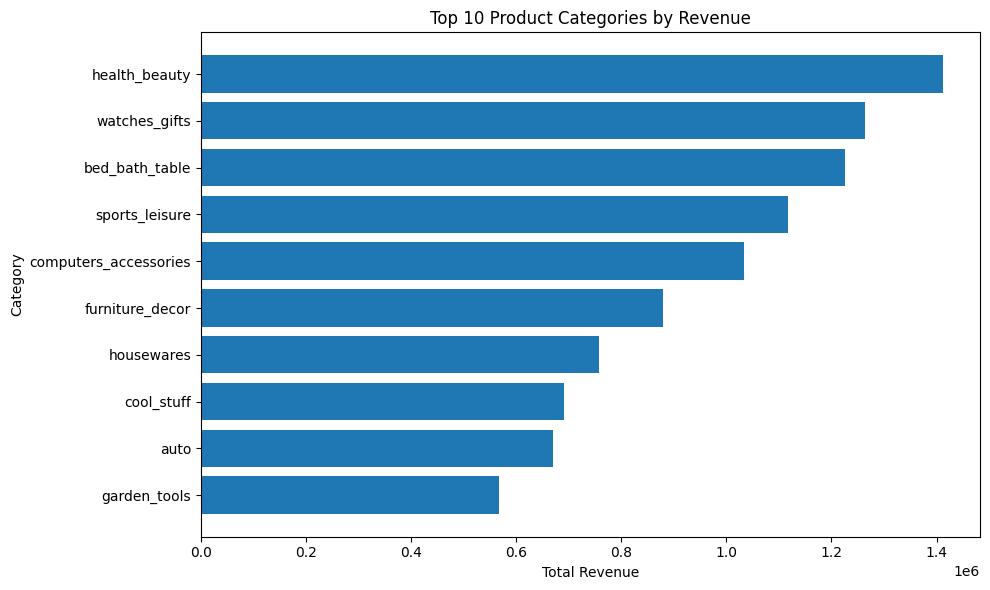

In [21]:
plt.figure(figsize=(10, 6))
plt.barh(category_revenue["category"][::-1], category_revenue["total_revenue"][::-1])
plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "top_categories_by_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

## 14. Payment Analysis

This section studies which payment methods are most common and how much revenue they generate.

In [22]:
payment_analysis = (
    payments
    .groupby("payment_type", as_index=False)
    .agg(
        total_orders=("order_id", "nunique"),
        total_payment_value=("payment_value", "sum"),
        avg_payment_value=("payment_value", "mean"),
        avg_installments=("payment_installments", "mean")
    )
    .sort_values("total_orders", ascending=False)
)

payment_analysis

,payment_type,total_orders,total_payment_value,avg_payment_value,avg_installments
1,credit_card,76505,"12,542,084.19",163.32,3.51
0,boleto,19784,"2,869,361.27",145.03,1.00
4,voucher,3866,"379,436.87",65.70,1.00
2,debit_card,1528,"217,989.79",142.57,1.00
3,not_defined,3,0.00,0.00,1.00


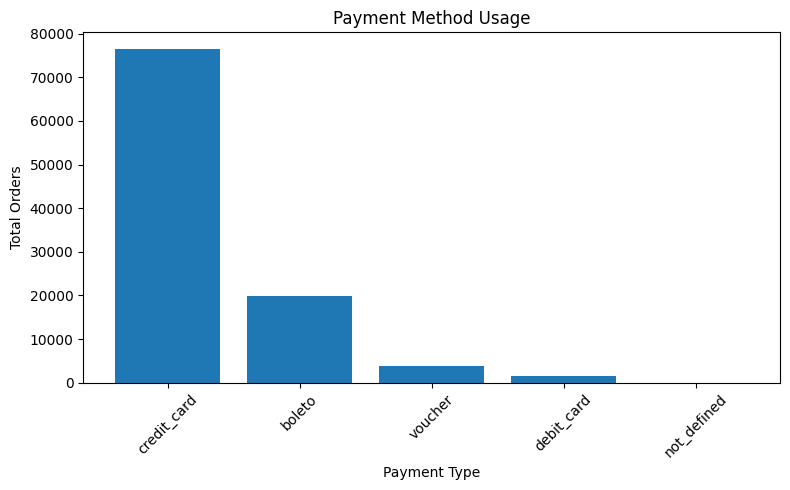

In [23]:
plt.figure(figsize=(8, 5))
plt.bar(payment_analysis["payment_type"], payment_analysis["total_orders"])
plt.title("Payment Method Usage")
plt.xlabel("Payment Type")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "payment_method_usage.png", dpi=300, bbox_inches="tight")
plt.show()

## 15. Delivery Performance

Delivery performance is measured using:

- average delivery days,
- late delivery count,
- and late delivery rate.

In [24]:
delivery_performance = delivered.dropna(subset=["order_delivered_customer_date", "order_estimated_delivery_date"]).copy()

delivery_summary = pd.DataFrame({
    "metric": [
        "Total delivered orders",
        "Average delivery days",
        "Late deliveries",
        "Late delivery rate (%)"
    ],
    "value": [
        delivery_performance["order_id"].nunique(),
        delivery_performance.groupby("order_id")["delivery_days"].mean().mean(),
        delivery_performance.loc[delivery_performance["is_late_delivery"] == 1, "order_id"].nunique(),
        delivery_performance.groupby("order_id")["is_late_delivery"].max().mean() * 100
    ]
})

delivery_summary

,metric,value
0,Total delivered orders,"96,470.00"
1,Average delivery days,12.09
2,Late deliveries,"6,534.00"
3,Late delivery rate (%),6.77


In [25]:
state_delay = (
    delivery_performance
    .groupby("customer_state", as_index=False)
    .agg(
        total_orders=("order_id", "nunique"),
        avg_delay_days=("delivery_delay_days", "mean"),
        late_rate=("is_late_delivery", "mean")
    )
    .sort_values("avg_delay_days", ascending=False)
    .head(15)
)

state_delay

,customer_state,total_orders,avg_delay_days,late_rate
1,AL,397,-8.74,0.21
9,MA,717,-9.91,0.18
24,SE,335,-10.00,0.16
7,ES,1995,-10.65,0.11
4,BA,3256,-10.98,0.12
5,CE,1279,-11.10,0.14
25,SP,40494,-11.21,0.04
11,MS,701,-11.23,0.09
16,PI,476,-11.53,0.14
23,SC,3546,-11.57,0.08


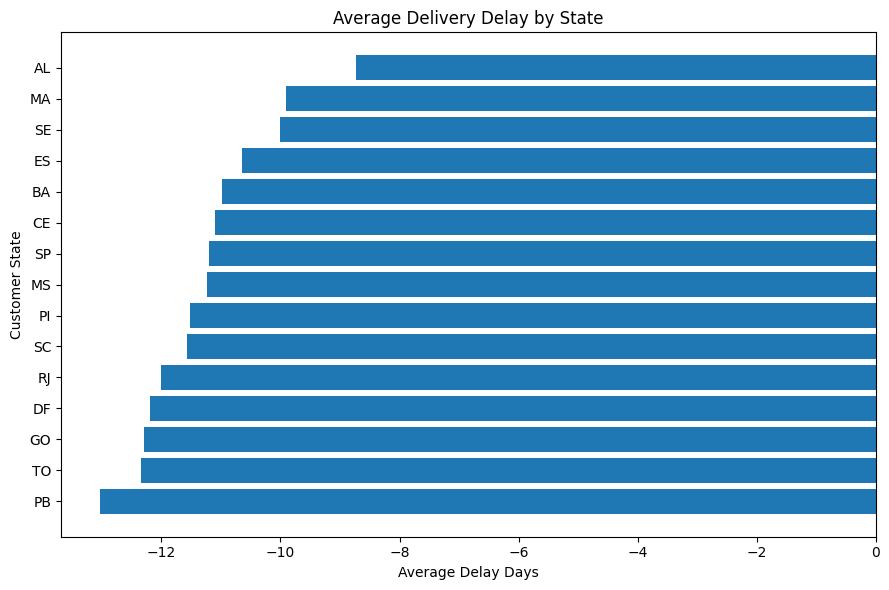

In [26]:
plt.figure(figsize=(9, 6))
plt.barh(state_delay["customer_state"][::-1], state_delay["avg_delay_days"][::-1])
plt.title("Average Delivery Delay by State")
plt.xlabel("Average Delay Days")
plt.ylabel("Customer State")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "delivery_delay_by_state.png", dpi=300, bbox_inches="tight")
plt.show()

## 16. Review Score Analysis

This section studies customer satisfaction using review scores.

In [27]:
review_distribution = (
    reviews["review_score"]
    .value_counts()
    .sort_index()
    .reset_index()
)

review_distribution.columns = ["review_score", "total_reviews"]
review_distribution

,review_score,total_reviews
0,1,11424
1,2,3151
2,3,8179
3,4,19142
4,5,57328


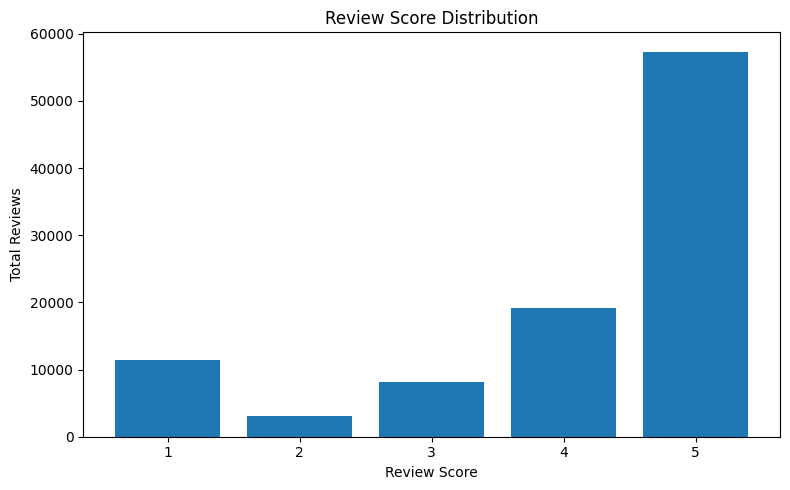

In [28]:
plt.figure(figsize=(8, 5))
plt.bar(review_distribution["review_score"].astype(str), review_distribution["total_reviews"])
plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Total Reviews")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "review_score_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 17. Customer Retention

This section calculates how many customers bought once and how many customers bought more than once.

In [29]:
customer_order_counts = (
    orders
    .merge(customers[["customer_id", "customer_unique_id"]], on="customer_id", how="left")
    .query("order_status == 'delivered'")
    .groupby("customer_unique_id", as_index=False)
    .agg(order_count=("order_id", "nunique"))
)

retention_summary = pd.DataFrame({
    "metric": ["One-time buyers", "Repeat buyers", "Total unique customers", "Repeat rate (%)"],
    "value": [
        (customer_order_counts["order_count"] == 1).sum(),
        (customer_order_counts["order_count"] > 1).sum(),
        customer_order_counts.shape[0],
        ((customer_order_counts["order_count"] > 1).mean() * 100).round(2)
    ]
})

retention_summary

,metric,value
0,One-time buyers,"90,557.00"
1,Repeat buyers,"2,801.00"
2,Total unique customers,"93,358.00"
3,Repeat rate (%),3.00


## 18. RFM Analysis

RFM analysis segments customers using:

- **Recency:** How recently the customer purchased.
- **Frequency:** How often the customer purchased.
- **Monetary:** How much the customer spent.

The SQL query calculates RFM scores from 1 to 5 using `NTILE(5)`.

In [30]:
rfm_query = """
WITH rfm AS (
    SELECT
        c.customer_unique_id,
        DATEDIFF(
            DAY,
            MAX(CAST(o.order_purchase_timestamp AS DATE)),
            (SELECT MAX(CAST(order_purchase_timestamp AS DATE))
             FROM olist_orders
             WHERE order_status = 'delivered')
        ) AS recency_days,
        COUNT(DISTINCT o.order_id) AS frequency,
        ROUND(SUM(i.price + i.freight_value), 2) AS monetary_value
    FROM olist_orders o
    JOIN olist_customers c 
        ON o.customer_id = c.customer_id
    JOIN olist_order_items i 
        ON o.order_id = i.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
),
rfm_scores AS (
    SELECT *,
        NTILE(5) OVER (ORDER BY recency_days DESC) AS recency_score,
        NTILE(5) OVER (ORDER BY frequency ASC) AS frequency_score,
        NTILE(5) OVER (ORDER BY monetary_value ASC) AS monetary_score
    FROM rfm
)
SELECT *,
    (recency_score + frequency_score + monetary_score) AS rfm_total_score,
    CASE
        WHEN recency_score >= 4 AND frequency_score >= 4 AND monetary_score >= 4
            THEN 'Best Customers'
        WHEN recency_score >= 4 AND frequency_score >= 3
            THEN 'Loyal Customers'
        WHEN recency_score <= 2 AND frequency_score >= 3
            THEN 'At Risk'
        WHEN recency_score >= 4 AND frequency_score <= 2
            THEN 'New Customers'
        ELSE 'Others'
    END AS customer_segment
FROM rfm_scores
ORDER BY rfm_total_score DESC;
"""

rfm = pd.read_sql(rfm_query, engine)
rfm.head()
rfm.shape
rfm["customer_segment"].value_counts()

customer_segment
Others             29977
At Risk            26039
New Customers      21318
Loyal Customers    10191
Best Customers      5833
Name: count, dtype: int64

In [31]:
rfm_segment_counts = (
    rfm["customer_segment"]
    .value_counts()
    .reset_index()
)

rfm_segment_counts.columns = ["customer_segment", "total_customers"]

rfm_segment_counts["percentage"] = (
    rfm_segment_counts["total_customers"] / rfm_segment_counts["total_customers"].sum() * 100
).round(2)

rfm_segment_counts

,customer_segment,total_customers,percentage
0,Others,29977,32.11
1,At Risk,26039,27.89
2,New Customers,21318,22.83
3,Loyal Customers,10191,10.92
4,Best Customers,5833,6.25


The RFM segment summary shows the number of customers, average recency, average frequency, and total monetary value for each customer segment.

This summary is useful for Power BI because it gives a business-level view of customer behavior.

In [32]:
rfm_segment_summary = (
    rfm
    .groupby("customer_segment", as_index=False)
    .agg(
        total_customers=("customer_unique_id", "nunique"),
        avg_recency_days=("recency_days", "mean"),
        avg_frequency=("frequency", "mean"),
        total_monetary_value=("monetary_value", "sum"),
        avg_monetary_value=("monetary_value", "mean"),
        avg_rfm_score=("rfm_total_score", "mean")
    )
    .sort_values("total_customers", ascending=False)
)

rfm_segment_summary["avg_recency_days"] = rfm_segment_summary["avg_recency_days"].round(2)
rfm_segment_summary["avg_frequency"] = rfm_segment_summary["avg_frequency"].round(2)
rfm_segment_summary["total_monetary_value"] = rfm_segment_summary["total_monetary_value"].round(2)
rfm_segment_summary["avg_monetary_value"] = rfm_segment_summary["avg_monetary_value"].round(2)
rfm_segment_summary["avg_rfm_score"] = rfm_segment_summary["avg_rfm_score"].round(2)

rfm_segment_summary

,customer_segment,total_customers,avg_recency_days,avg_frequency,total_monetary_value,avg_monetary_value,avg_rfm_score
4,Others,29977,297.38,1.02,"4,777,550.01",159.37,8.10
0,At Risk,26039,380.16,1.04,"4,317,972.39",165.83,8.27
3,New Customers,21318,86.93,1.00,"3,540,454.11",166.08,8.97
2,Loyal Customers,10191,91.84,1.02,"975,601.05",95.73,10.96
1,Best Customers,5833,97.36,1.20,"1,808,196.19",309.99,13.61


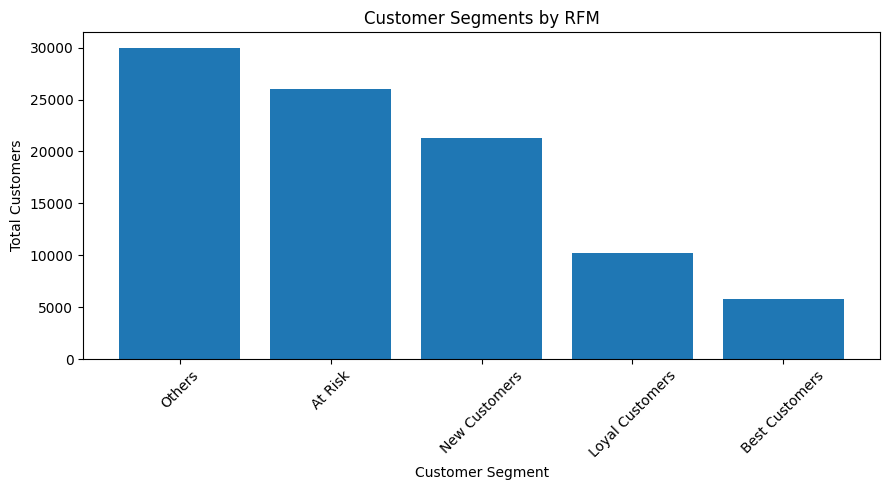

In [33]:
plt.figure(figsize=(9, 5))
plt.bar(rfm_segment_summary["customer_segment"], rfm_segment_summary["total_customers"])
plt.title("Customer Segments by RFM")
plt.xlabel("Customer Segment")
plt.ylabel("Total Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rfm_customer_segments.png", dpi=300, bbox_inches="tight")
plt.show()

## 19. Monthly Cancellation Analysis

This section tracks monthly cancellation and delivery rates.

In [34]:
cancellation_query = """
SELECT
    DATEFROMPARTS(
        YEAR(order_purchase_timestamp),
        MONTH(order_purchase_timestamp),
        1
    ) AS order_month,

    COUNT(*) AS total_orders,

    SUM(CASE WHEN order_status = 'delivered'
             THEN 1 ELSE 0 END) AS delivered_orders,

    SUM(CASE WHEN order_status = 'canceled'
             THEN 1 ELSE 0 END) AS canceled_orders,

    SUM(CASE WHEN order_status NOT IN ('delivered', 'canceled')
             THEN 1 ELSE 0 END) AS other_status_orders,

    ROUND(
        SUM(CASE WHEN order_status = 'canceled'
                 THEN 1 ELSE 0 END) * 100.0 / COUNT(*),
        2
    ) AS cancellation_rate_pct,

    ROUND(
        SUM(CASE WHEN order_status = 'delivered'
                 THEN 1 ELSE 0 END) * 100.0 / COUNT(*),
        2
    ) AS delivery_rate_pct

FROM olist_orders
WHERE order_purchase_timestamp IS NOT NULL
GROUP BY DATEFROMPARTS(
    YEAR(order_purchase_timestamp),
    MONTH(order_purchase_timestamp),
    1
)
ORDER BY order_month;
"""

cancellation = pd.read_sql(cancellation_query, engine)
cancellation["order_month"] = pd.to_datetime(cancellation["order_month"])
cancellation

,order_month,total_orders,delivered_orders,canceled_orders,other_status_orders,cancellation_rate_pct,delivery_rate_pct
0,2016-09-01,4,1,2,1,50.00,25.00
1,2016-10-01,324,265,24,35,7.41,81.79
2,2016-12-01,1,1,0,0,0.00,100.00
3,2017-01-01,800,750,3,47,0.38,93.75
4,2017-02-01,1780,1653,17,110,0.96,92.87
5,2017-03-01,2682,2546,33,103,1.23,94.93
6,2017-04-01,2404,2303,18,83,0.75,95.80
7,2017-05-01,3700,3546,29,125,0.78,95.84
8,2017-06-01,3245,3135,16,94,0.49,96.61
9,2017-07-01,4026,3872,28,126,0.70,96.17


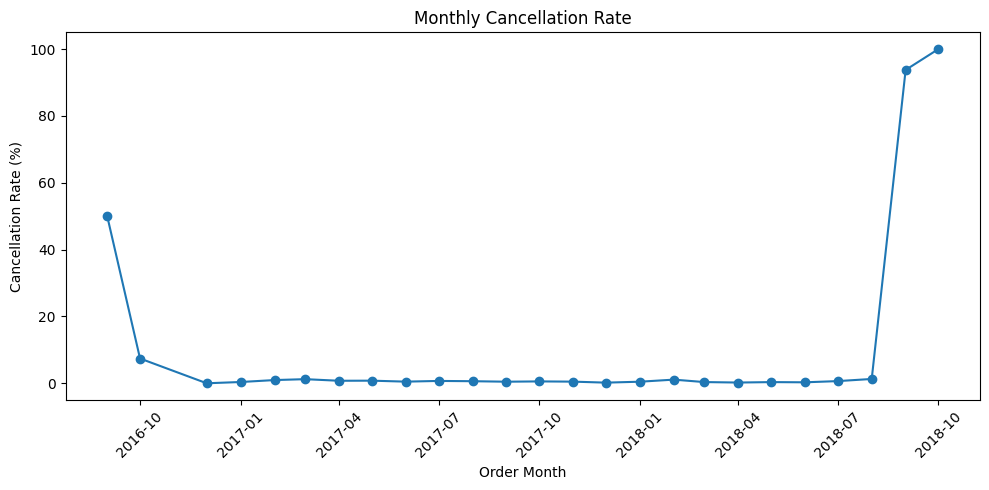

In [35]:
plt.figure(figsize=(10, 5))
plt.plot(cancellation["order_month"], cancellation["cancellation_rate_pct"], marker="o")
plt.title("Monthly Cancellation Rate")
plt.xlabel("Order Month")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "monthly_cancellation_rate.png", dpi=300, bbox_inches="tight")
plt.show()

## 20. Export Cleaned Outputs

These exported CSV files will be useful for:

- Power BI dashboard building,
- GitHub project documentation,
- and the next time series forecasting notebook.

In [36]:
master_sample_path = REPORTS_DIR / "master_dataset_sample.csv"
monthly_path = REPORTS_DIR / "monthly_sales_for_time_series.csv"
rfm_path = REPORTS_DIR / "rfm_customer_segments.csv"
cancellation_path = REPORTS_DIR / "monthly_cancellation_analysis.csv"

master.head(5000).to_csv(master_sample_path, index=False)
monthly_sales.to_csv(monthly_path, index=False)
rfm.to_csv(rfm_path, index=False)
cancellation.to_csv(cancellation_path, index=False)

print("Exported files:")
print(master_sample_path)
print(monthly_path)
print(rfm_path)
print(cancellation_path)

Exported files:
C:\Users\ayush\OneDrive\Desktop\OlistProject\reports\master_dataset_sample.csv
C:\Users\ayush\OneDrive\Desktop\OlistProject\reports\monthly_sales_for_time_series.csv
C:\Users\ayush\OneDrive\Desktop\OlistProject\reports\rfm_customer_segments.csv
C:\Users\ayush\OneDrive\Desktop\OlistProject\reports\monthly_cancellation_analysis.csv


## 21. Summary of Phase 2

In this notebook, we completed:

- SQL Server connection from Jupyter Notebook,
- loading 9 Olist tables from SQL Server,
- missing value and duplicate key checks,
- master analytical dataset creation,
- feature engineering,
- business KPI analysis,
- order, product, payment, delivery, review, and customer analysis,
- RFM customer segmentation,
- monthly cancellation analysis,
- and export of the monthly sales dataset for time series forecasting.



## Power BI Export Tables

This section creates clean summary tables that will be used in Power BI dashboard building.

The exported tables include KPIs, monthly sales trends, order status distribution, category performance, seller performance, customer state analysis, delivery performance, and review analysis.

In [37]:
POWERBI_DIR = REPORTS_DIR / "powerbi_exports"
POWERBI_DIR.mkdir(exist_ok=True)

print("Power BI export folder:", POWERBI_DIR)

Power BI export folder: C:\Users\ayush\OneDrive\Desktop\OlistProject\reports\powerbi_exports


In [38]:
delivered = master[master["order_status"] == "delivered"].copy()

order_level = (
    delivered
    .groupby("order_id", as_index=False)
    .agg(
        customer_id=("customer_id", "first"),
        customer_unique_id=("customer_unique_id", "first"),
        order_value=("order_value", "sum"),
        avg_review_score=("avg_review_score", "mean"),
        delivery_days=("delivery_days", "mean"),
        delivery_delay_days=("delivery_delay_days", "mean"),
        is_late_delivery=("is_late_delivery", "max")
    )
)

kpi_summary_powerbi = pd.DataFrame({
    "metric": [
        "Total Delivered Orders",
        "Total Unique Customers",
        "Total Sellers",
        "Total Products Sold",
        "Total Revenue",
        "Average Order Value",
        "Average Review Score",
        "Average Delivery Days",
        "Late Delivery Rate (%)"
    ],
    "value": [
        order_level["order_id"].nunique(),
        order_level["customer_unique_id"].nunique(),
        delivered["seller_id"].nunique(),
        delivered["product_id"].nunique(),
        order_level["order_value"].sum(),
        order_level["order_value"].mean(),
        order_level["avg_review_score"].mean(),
        order_level["delivery_days"].mean(),
        order_level["is_late_delivery"].mean() * 100
    ]
})

kpi_summary_powerbi["value"] = kpi_summary_powerbi["value"].round(2)

kpi_summary_powerbi.to_csv(POWERBI_DIR / "kpi_summary.csv", index=False)

kpi_summary_powerbi

,metric,value
0,Total Delivered Orders,"96,478.00"
1,Total Unique Customers,"93,358.00"
2,Total Sellers,"2,970.00"
3,Total Products Sold,"32,216.00"
4,Total Revenue,"15,419,773.75"
5,Average Order Value,159.83
6,Average Review Score,4.16
7,Average Delivery Days,12.09
8,Late Delivery Rate (%),6.77


In [39]:
order_status_summary = (
    orders["order_status"]
    .value_counts()
    .reset_index()
)

order_status_summary.columns = ["order_status", "total_orders"]

order_status_summary["percentage"] = (
    order_status_summary["total_orders"] / order_status_summary["total_orders"].sum() * 100
).round(2)

order_status_summary.to_csv(POWERBI_DIR / "order_status_summary.csv", index=False)

order_status_summary

,order_status,total_orders,percentage
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


In [40]:
monthly_sales.to_csv(POWERBI_DIR / "monthly_sales.csv", index=False)

monthly_sales.head()

,order_month,total_orders,total_revenue,product_revenue,freight_revenue,avg_item_price,avg_order_value,avg_review_score
0,2016-09-01,1,143.46,134.97,8.49,44.99,143.46,1.00
1,2016-10-01,265,"46,490.66","40,325.11","6,165.55",128.83,175.44,4.01
2,2016-12-01,1,19.62,10.90,8.72,10.90,19.62,5.00
3,2017-01-01,750,"127,482.37","111,798.36","15,684.01",122.45,169.98,4.20
4,2017-02-01,1653,"271,239.32","234,223.40","37,015.92",126.06,164.09,4.20


In [41]:
category_performance = (
    delivered
    .groupby("product_category_name_english", as_index=False)
    .agg(
        total_revenue=("order_value", "sum"),
        total_orders=("order_id", "nunique"),
        total_items_sold=("order_item_id", "count"),
        avg_review_score=("avg_review_score", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)

category_performance["total_revenue"] = category_performance["total_revenue"].round(2)
category_performance["avg_review_score"] = category_performance["avg_review_score"].round(2)

category_performance.to_csv(POWERBI_DIR / "category_performance.csv", index=False)

category_performance.head(10)

,product_category_name_english,total_revenue,total_orders,total_items_sold,avg_review_score
43,health_beauty,"1,412,089.53",8647,9465,4.19
70,watches_gifts,"1,264,333.12",5495,5859,4.07
7,bed_bath_table,"1,225,209.26",9272,10953,3.92
65,sports_leisure,"1,118,256.91",7530,8431,4.17
15,computers_accessories,"1,032,723.77",6530,7644,3.99
39,furniture_decor,"880,329.92",6307,8160,3.95
49,housewares,"758,392.25",5743,6795,4.11
20,cool_stuff,"691,680.89",3559,3718,4.19
5,auto,"669,454.75",3810,4140,4.12
42,garden_tools,"567,145.68",3448,4268,4.08


In [42]:
seller_performance = (
    delivered
    .groupby("seller_id", as_index=False)
    .agg(
        total_revenue=("order_value", "sum"),
        total_orders=("order_id", "nunique"),
        total_items_sold=("order_item_id", "count"),
        avg_review_score=("avg_review_score", "mean"),
        avg_delivery_days=("delivery_days", "mean"),
        late_delivery_rate=("is_late_delivery", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)

seller_performance["total_revenue"] = seller_performance["total_revenue"].round(2)
seller_performance["avg_review_score"] = seller_performance["avg_review_score"].round(2)
seller_performance["avg_delivery_days"] = seller_performance["avg_delivery_days"].round(2)
seller_performance["late_delivery_rate"] = (seller_performance["late_delivery_rate"] * 100).round(2)

seller_performance.to_csv(POWERBI_DIR / "seller_performance.csv", index=False)

seller_performance.head(10)

,seller_id,total_revenue,total_orders,total_items_sold,avg_review_score,avg_delivery_days,late_delivery_rate
834,4869f7a5dfa277a7dca6462dcf3b52b2,"247,007.06",1124,1148,4.14,14.55,10.54
1480,7c67e1448b00f6e969d365cea6b010ab,"237,806.69",973,1355,3.35,21.95,8.86
858,4a3ca9315b744ce9f8e9374361493884,"231,220.43",1772,1949,3.83,13.94,9.70
982,53243585a1d6dc2643021fd1853d8905,"230,797.02",348,400,4.13,12.94,3.00
2903,fa1c13f2614d7b5c4749cbc52fecda94,"200,833.50",578,579,4.37,12.84,9.15
2543,da8622b14eb17ae2831f4ac5b9dab84a,"184,706.78",1311,1548,4.07,10.70,6.40
1504,7e93a43ef30c4f03f38b393420bc753a,"171,973.55",319,322,4.36,10.83,4.66
188,1025f0e2d44d7041d6cf58b6550e0bfa,"171,924.96",910,1420,3.87,11.57,6.69
1450,7a67c85e85bb2ce8582c35f2203ad736,"160,278.52",1145,1155,4.27,10.69,5.19
1758,955fee9216a65b617aa5c0531780ce60,"156,606.48",1261,1472,4.09,10.30,6.45


In [43]:
customer_state_analysis = (
    order_level
    .merge(
        customers[["customer_id", "customer_state", "customer_city"]],
        on="customer_id",
        how="left"
    )
    .groupby("customer_state", as_index=False)
    .agg(
        total_orders=("order_id", "nunique"),
        total_customers=("customer_unique_id", "nunique"),
        total_revenue=("order_value", "sum"),
        avg_order_value=("order_value", "mean"),
        avg_review_score=("avg_review_score", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)

customer_state_analysis["total_revenue"] = customer_state_analysis["total_revenue"].round(2)
customer_state_analysis["avg_order_value"] = customer_state_analysis["avg_order_value"].round(2)
customer_state_analysis["avg_review_score"] = customer_state_analysis["avg_review_score"].round(2)

customer_state_analysis.to_csv(POWERBI_DIR / "customer_state_analysis.csv", index=False)

customer_state_analysis.head(10)

,customer_state,total_orders,total_customers,total_revenue,avg_order_value,avg_review_score
25,SP,40501,39156,"5,769,703.15",142.46,4.25
18,RJ,12350,11917,"2,055,401.57",166.43,3.97
10,MG,11354,11001,"1,818,891.67",160.20,4.19
22,RS,5345,5168,"861,472.79",161.17,4.19
17,PR,4923,4769,"781,708.80",158.79,4.24
23,SC,3546,3449,"595,127.78",167.83,4.13
4,BA,3256,3158,"591,137.81",181.55,3.93
6,DF,2080,2019,"346,123.35",166.41,4.13
8,GO,1957,1895,"334,212.35",170.78,4.10
7,ES,1995,1928,"317,657.93",159.23,4.08


In [44]:
delivery_performance = (
    order_level
    .assign(
        delivery_status=np.where(
            order_level["is_late_delivery"] == 1,
            "Late",
            "On Time / Early"
        )
    )
    .groupby("delivery_status", as_index=False)
    .agg(
        total_orders=("order_id", "nunique"),
        avg_delivery_days=("delivery_days", "mean"),
        avg_delay_days=("delivery_delay_days", "mean"),
        avg_review_score=("avg_review_score", "mean")
    )
)

delivery_performance["avg_delivery_days"] = delivery_performance["avg_delivery_days"].round(2)
delivery_performance["avg_delay_days"] = delivery_performance["avg_delay_days"].round(2)
delivery_performance["avg_review_score"] = delivery_performance["avg_review_score"].round(2)

delivery_performance.to_csv(POWERBI_DIR / "delivery_performance.csv", index=False)

delivery_performance

,delivery_status,total_orders,avg_delivery_days,avg_delay_days,avg_review_score
0,Late,6534,33.49,10.62,2.27
1,On Time / Early,89944,10.54,-13.51,4.29


In [45]:
review_score_summary = (
    reviews
    .groupby("review_score", as_index=False)
    .agg(total_reviews=("review_id", "count"))
    .sort_values("review_score")
)

review_score_summary["percentage"] = (
    review_score_summary["total_reviews"] / review_score_summary["total_reviews"].sum() * 100
).round(2)

review_score_summary.to_csv(POWERBI_DIR / "review_score_summary.csv", index=False)

review_score_summary

,review_score,total_reviews,percentage
0,1,11424,11.51
1,2,3151,3.18
2,3,8179,8.24
3,4,19142,19.29
4,5,57328,57.78


In [46]:
rfm.to_csv(POWERBI_DIR / "rfm_customer_scores.csv", index=False)
rfm_segment_summary.to_csv(POWERBI_DIR / "rfm_segment_summary.csv", index=False)
rfm_segment_counts.to_csv(POWERBI_DIR / "rfm_segment_counts.csv", index=False)


print("Saved:", POWERBI_DIR / "rfm_customer_scores.csv")
print("Saved:", POWERBI_DIR / "rfm_segment_summary.csv")

Saved: C:\Users\ayush\OneDrive\Desktop\OlistProject\reports\powerbi_exports\rfm_customer_scores.csv
Saved: C:\Users\ayush\OneDrive\Desktop\OlistProject\reports\powerbi_exports\rfm_segment_summary.csv
